# Análisis exploratorio de variables clínicas y mutacionales asociadas a la clasificación histológica (LGG vs. GBM)

## Dataset

El conjunto de datos utilizado para el análisis es `TCGA_InfoWithGrade.csv`,
correspondiente a una versión preprocesada de los datos relacionados con
gliomas del proyecto The Cancer Genome Atlas (TCGA).

In [63]:
# Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from scipy.stats import chi2_contingency, ttest_ind

sns.set_theme(context="notebook", style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.edgecolor": "0.3",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "legend.frameon": False,
    "figure.facecolor": "white",
})

# Paleta institucional: dos tonos para LGG (0) vs GBM (1)
PALETTE_GRADE = {0: "#2E86AB", 1: "#C1443C"}
PALETTE_SEQ   = sns.color_palette("mako", as_cmap=False)

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

df = pd.read_csv("TCGA_InfoWithGrade.csv")
df.head()

,Grade,Gender,Age_at_diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,PIK3CA,NF1,PIK3R1,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,0,0,51.30,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0
1,0,0,38.72,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,35.17,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,1,32.78,0,1,1,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0
4,0,0,31.51,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [5]:
df.tail()

,Grade,Gender,Age_at_diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
834,1,1,77.89,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
835,1,0,85.18,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
836,1,1,77.49,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
837,1,0,63.33,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
838,1,0,76.61,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Estructura

In [28]:
info_df = pd.DataFrame({
    "Tipo de dato": df.dtypes.astype(str),
    "Valores no nulos": df.notna().sum().values,
    "Valores nulos": df.isna().sum().values,
    "Valores únicos": df.nunique()
})
print(f"Dimensiones del dataset: {df.shape[0]} pacientes x {df.shape[1]} variables")
print(f"Registros duplicados: {df.duplicated().sum()}")
print(f"Valores faltantes: {df.isnull().sum().sum()}")
info_df

Dimensiones del dataset: 839 pacientes x 24 variables
Registros duplicados: 1
Valores faltantes: 0


,Tipo de dato,Valores no nulos,Valores nulos,Valores únicos
Grade,category,839,0,2
Gender,category,839,0,2
Age_at_diagnosis,float64,839,0,766
Race,category,839,0,4
IDH1,category,839,0,2
TP53,category,839,0,2
ATRX,category,839,0,2
PTEN,category,839,0,2
EGFR,category,839,0,2
CIC,category,839,0,2


In [44]:
columnas_categoricas = df.columns.difference(["Age_at_diagnosis"])
df[columnas_categoricas] = df[columnas_categoricas].astype("category")

pd.DataFrame({
    "Tipo": df.dtypes.astype(str)
}).T

,Grade,Gender,Age_at_diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,PIK3CA,NF1,PIK3R1,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
Tipo,category,category,float64,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category


El conjunto de datos presenta una estructura limpia y estructurada, compuesta por **839 registros** (pacientes) y **24 variables**, sin presencia de valores nulos o faltantes. Aunque se presente un registro duplicado representa a dos pacientes distintos que casualmente comparten el mismo fenotipo y perfil genético, ya que su ID es distinto en el dataset original. Las variables binarias, originalmente codificadas mediante valores enteros `0` y `1`, fueron transformadas al tipo categórico (`category`) para representar adecuadamente su naturaleza y facilitar su análisis exploratorio.

## Contexto de los datos

| Categoría | Variables | Codificación |
|---|---|---|
| **Variable objetivo** | `Grade` | 0 = LGG (glioma de bajo grado), 1 = GBM (glioblastoma) |
| **Demográficas** | `Gender`, `Age_at_diagnosis`, `Race` | `Gender`: 0/1; `Race`: 0–3 (categorías étnicas codificadas); `Age`: continua (años) |
| **Mutacionales** | 20 genes (`IDH1`, `TP53`, `ATRX`, `PTEN`, `EGFR`, `CIC`, `MUC16`, `PIK3CA`, `NF1`, `PIK3R1`, `FUBP1`, `RB1`, `NOTCH1`, `BCOR`, `CSMD3`, `SMARCA4`, `GRIN2A`, `IDH2`, `FAT4`, `PDGFRA`) | 0 = no mutado, 1 = mutado |

### Variable Objetivo

- **`Grade`**: Indica el grado del glioma (0 = `LGG`, 1 = `GBM`). Esta variable distingue entre los dos grupos principales del conjunto de datos: Glioma de Bajo Grado (*Low-Grade Glioma*) y Glioblastoma Multiforme (*Glioblastoma Multiforme*).

---

### Variables Clínicas

Proporcionan información sobre las características demográficas de los pacientes:

- **`Gender`**: Género del paciente (0 = masculino, 1 = femenino).
- **`Age_at_diagnosis`**: Edad del paciente al momento del diagnóstico expresada en años (numérica continua). La parte decimal incorpora la información exacta de los días transcurridos.
- **`Race`**: Raza reportada del paciente codificada del 0 al 3 (0 = *White*, 1 = *Black or African American*, 2 = *Asian*, 3 = *American Indian or Alaska Native*).

---


### Variables genéticas

El conjunto de datos también contiene variables correspondientes a
diferentes genes. Estas variables están codificadas de forma binaria,
indicando con un valor de **1** la presencia de una mutación en el gen
correspondiente, y con un **0** la condición de gen salvaje / no mutado (*wildtype*):

- **`IDH1`**: Codifica una enzima involucrada en el metabolismo celular.

- **`TP53`**: Gen supresor tumoral que participa en el control del ciclo celular y en la respuesta al daño del ADN. Sus alteraciones favorecen la proliferación tumoral.

- **`ATRX`**: Participa en el mantenimiento de la estructura de la
  cromatina y en la estabilidad del genoma.

- **`PTEN`**: Gen supresor tumoral que regula vías relacionadas con el
  crecimiento y la supervivencia celular.

- **`EGFR`**: Codifica un receptor involucrado en señales de crecimiento y proliferación celular.

- **`CIC`**: Participa en la regulación de la expresión de otros genes y en procesos relacionados con el desarrollo celular.

- **`MUC16`**: Codifica una proteína de gran tamaño asociada a la
  superficie celular.

- **`PIK3CA`**: Participa en la vía de señalización PI3K/AKT, relacionada con crecimiento, supervivencia y proliferación celular.

- **`NF1`**: Actúa como regulador negativo de señales relacionadas con el crecimiento celular. Sus alteraciones pueden contribuir a la proliferación tumoral.

- **`PIK3R1`**: Codifica una subunidad reguladora de la vía PI3K, que
  interviene en procesos de crecimiento y supervivencia celular.

- **`FUBP1`**: Participa en la regulación de la expresión génica y del
  crecimiento celular.

- **`RB1`**: Gen supresor tumoral que participa en el control del ciclo celular y regula la progresión de las células hacia la división.

- **`NOTCH1`**: Forma parte de la vía de señalización Notch, relacionada con la diferenciación, proliferación y supervivencia celular.

- **`BCOR`**: Participa en la regulación de la expresión génica mediante complejos relacionados con la cromatina.

- **`CSMD3`**: Codifica una proteína de gran tamaño y se encuentra entre los genes que pueden presentar mutaciones en distintos tumores.

- **`SMARCA4`**: Participa en la remodelación de la cromatina y, por
  tanto, en la regulación de la expresión de los genes.

- **`GRIN2A`**: Codifica una subunidad de un receptor de glutamato,
  relacionado principalmente con la señalización neuronal.

- **`IDH2`**: Codifica una enzima metabólica relacionada con IDH1.

- **`FAT4`**: Participa en procesos relacionados con la organización,
  adhesión y crecimiento de las células.

- **`PDGFRA`**: Codifica un receptor involucrado en señales de
  crecimiento y proliferación celular.

---

El dataset está compuesto por **24 variables en total**:
* **Variable Objetivo (Target):** `Grade` (binaria: 0 = LGG, 1 = GBM).
* **21 atributos binarios (0/1):** `Gender` y las 20 mutaciones genéticas evaluadas.
* **1 atributo categórico politómico:** `Race` (codificada en 4 niveles).
* **1 atributo continuo:** `Age_at_diagnosis` (`float64`, expresada en años).

El objetivo a resolver es predecir la severidad del glioma en pacientes, clasificándolos entre Glioma de Bajo Grado (**LGG**) y Glioblastoma Multiforme (**GBM**) a partir de sus características clínicas y perfil de mutaciones genéticas.


## División del dataset - Protocolo Anti-Leakage

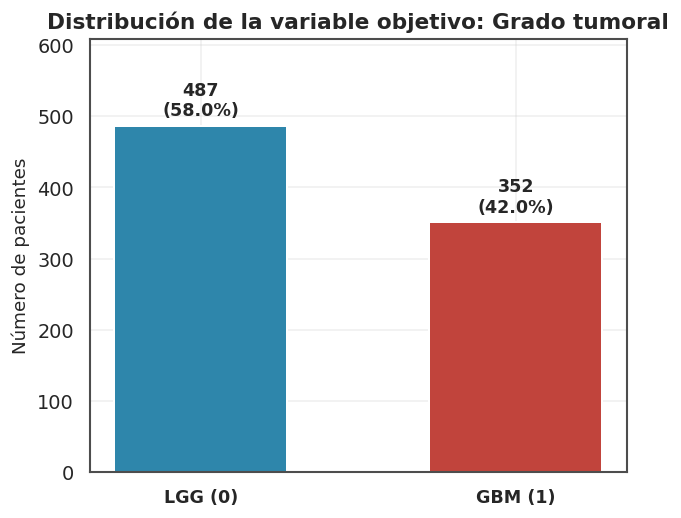

In [55]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))

conteo = df["Grade"].value_counts()
proporcion = conteo / conteo.sum() * 100

bars = ax.bar(conteo.index, conteo.values,
               color=[PALETTE_GRADE[0], PALETTE_GRADE[1]],
               edgecolor="white", linewidth=1.2, width=0.55)

for bar, c, p in zip(bars, conteo.values, proporcion.values):
    ax.text(bar.get_x() + bar.get_width()/2, c + 8,
            f"{c}\n({p:.1f}%)", ha="center", va="bottom", fontsize=10.5, fontweight="bold")

ax.set_xticks([0, 1])
ax.set_xticklabels(['LGG (0)', 'GBM (1)'], fontsize=10.5, fontweight='bold')
ax.set_ylabel("Número de pacientes")
ax.set_xlabel("")
ax.set_title("Distribución de la variable objetivo: Grado tumoral")
ax.set_ylim(0, conteo.max() * 1.25)
plt.tight_layout()
plt.show()

La elección de una partición estratificada (Stratified Train-Test Split) se justifica por la necesidad de preservar la proporción original de las clases de la variable objetivo (`Grade`) en ambos subconjuntos de datos. En el dataset completo, la distribución presenta un ligero desbalance (ratio ≈ 1.4:1), donde el 58.05% corresponde a Gliomas de Bajo Grado (LGG) y el 41.95% a Glioblastomas (GBM), una división sin estratificar podría dejar los conjuntos de `train` y `test` sesgados a un solo grupo de la variable `Grade`.

In [56]:
x = df.drop(columns=['Grade'])
y = df['Grade']

X_train, X_test, y_train, y_test = train_test_split(
    x, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

train_data = pd.concat([X_train, y_train], axis=1)

Para asegurar una evaluación rigurosa del modelo y prevenir la fuga de datos, el conjunto original de 839 registros se dividió en una proporción 80/20 mediante una partición estratificada basada en la variable objetivo (`Grade`). De este modo, se reservó un conjunto de prueba (*Test set*) compuesto por 168 pacientes exclusivamente para la validación final del rendimiento, mientras que las 671 observaciones restantes formaron el conjunto de entrenamiento (*Train set*), garantizando que el patrón de distribución de las clases —aproximadamente 58% para tumores de bajo grado (LGG) y 42% para glioblastomas (GBM)— se mantuviera perfectamente balanceado entre ambas subdivisiones.

## Análisis Univariado de variables

### Análisis de la variable `Grade` (Target)

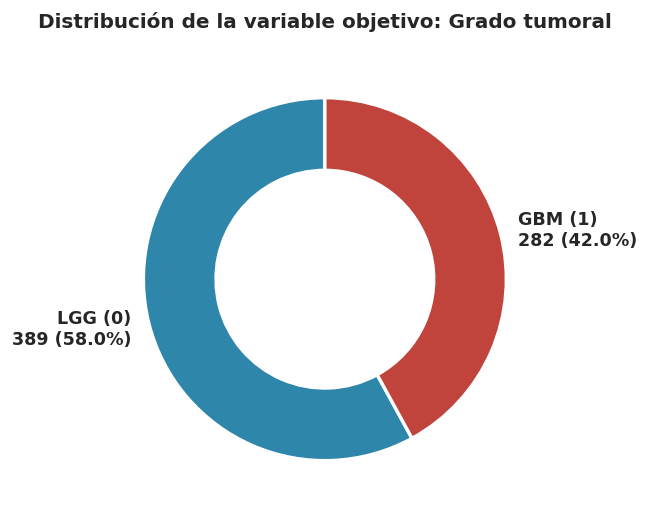

In [60]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))

conteo = y_train.value_counts()
proporcion = (conteo / conteo.sum()) * 100

labels = [
    f"LGG (0)\n{conteo[0]} ({proporcion[0]:.1f}%)",
    f"GBM (1)\n{conteo[1]} ({proporcion[1]:.1f}%)",
]

wedges, texts = ax.pie(
    conteo.values,
    labels=labels,
    colors=[PALETTE_GRADE[0], PALETTE_GRADE[1]],
    startangle=90,
    wedgeprops=dict(
        width=0.4, edgecolor="white", linewidth=2
    ), 
    textprops=dict(fontsize=10.5, fontweight="bold"),
)

ax.set_title(
    "Distribución de la variable objetivo: Grado tumoral",
    pad=15,
    fontsize=12,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

En el conjunto de entrenamiento (671 pacientes), la variable objetivo `Grade` presenta una distribución de 389 casos correspondientes a Gliomas de Bajo Grado (LGG, 58.0%) y 282 casos a Glioblastoma Multiforme (GBM, 42.0%). La relación entre clases es aproximadamente de **1.38 a 1**, lo que indica que **no hay un desbalance severo**.

### Análisis de las variables independientes

#### `Age_at_diagnosis`

In [76]:
age_series = train_data['Age_at_diagnosis']

mean_age = age_series.mean()
std_age = age_series.std()
median_age = age_series.median()
q1_age = age_series.quantile(0.25)
q3_age = age_series.quantile(0.75)
iqr_age = q3_age - q1_age
min_age = age_series.min()
max_age = age_series.max()
skew_age = age_series.skew()
kurt_age = age_series.kurt()

summary_age = pd.DataFrame({
    'Métrica Estadística': [
        'Total de Muestras (n)', 'Media (μ)', 'Desviación Estándar (σ)',
        'Mínimo', 'Primer Cuartil (Q1)', 'Mediana (Q2)',
        'Tercer Cuartil (Q3)', 'Máximo', 'Rango Intercuartílico (IQR)',
        'Asimetría (Skewness)', 'Curtosis'
    ],
    'Valor': [
        f"{len(age_series)}", f"{mean_age:.2f} años", f"{std_age:.2f} años",
        f"{min_age:.2f} años", f"{q1_age:.2f} años", f"{median_age:.2f} años",
        f"{q3_age:.2f} años", f"{max_age:.2f} años", f"{iqr_age:.2f} años",
        f"{skew_age:.4f}", f"{kurt_age:.4f}"
    ]
})

print("TABLA RESUMEN: EDAD AL DIAGNÓSTICO")
summary_age

TABLA RESUMEN: EDAD AL DIAGNÓSTICO


,Métrica Estadística,Valor
0,Total de Muestras (n),671
1,Media (μ),51.10 años
2,Desviación Estándar (σ),15.63 años
3,Mínimo,14.42 años
4,Primer Cuartil (Q1),37.84 años
5,Mediana (Q2),51.99 años
6,Tercer Cuartil (Q3),62.62 años
7,Máximo,89.29 años
8,Rango Intercuartílico (IQR),24.79 años
9,Asimetría (Skewness),0.0547


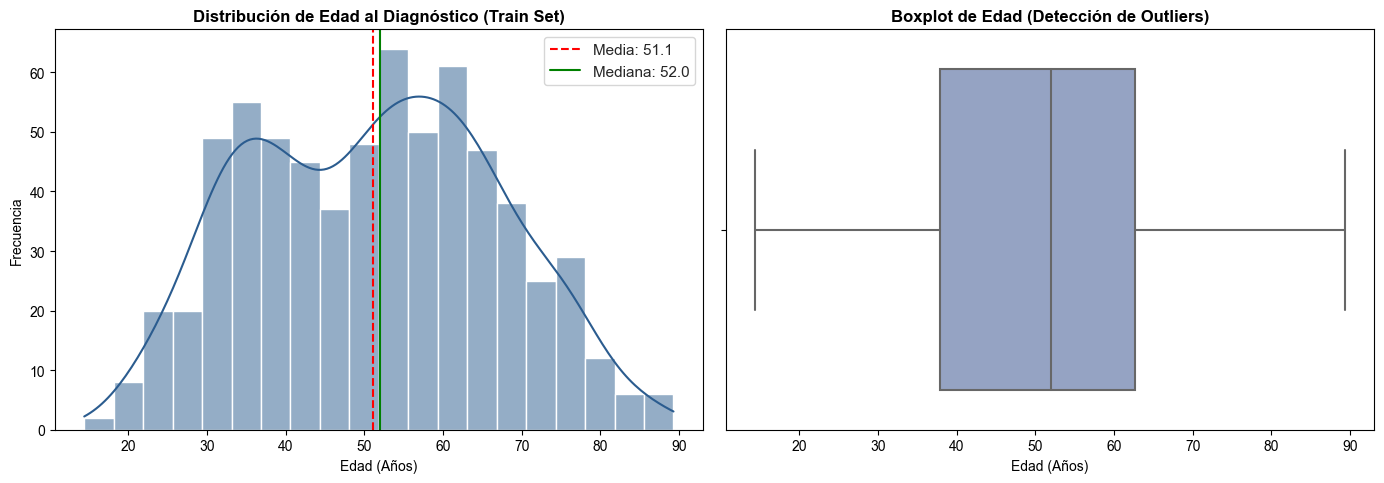

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="whitegrid")

sns.histplot(data=X_train, x='Age_at_diagnosis', kde=True, ax=axes[0], color='#2b5c8f', bins=20)
axes[0].set_title('Distribución de Edad al Diagnóstico (Train Set)', fontweight='bold')
axes[0].set_xlabel('Edad (Años)')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(X_train['Age_at_diagnosis'].mean(), color='red', linestyle='--', label=f'Media: {X_train["Age_at_diagnosis"].mean():.1f}')
axes[0].axvline(X_train['Age_at_diagnosis'].median(), color='green', linestyle='-', label=f'Mediana: {X_train["Age_at_diagnosis"].median():.1f}')
axes[0].legend()

sns.boxplot(data=X_train, x='Age_at_diagnosis', ax=axes[1], color='#8da0cb')
axes[1].set_title('Boxplot de Edad (Detección de Outliers)', fontweight='bold')
axes[1].set_xlabel('Edad (Años)')

plt.tight_layout()
plt.show()

In [ ]:
q1 = X_train['Age_at_diagnosis'].quantile(0.25)
q3 = X_train['Age_at_diagnosis'].quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers = X_train[(X_train['Age_at_diagnosis'] < limite_inferior) | 
                   (X_train['Age_at_diagnosis'] > limite_superior)]

print("EVALUACIÓN MATEMÁTICA DE OUTLIERS (MÉTODO IQR)")
print(f"• Límite Inferior Aceptable: {limite_inferior:.2f} años")
print(f"• Límite Superior Aceptable: {limite_superior:.2f} años")
print(f"• Cantidad de outliers detectados: {len(outliers)}")

62.625
EVALUACIÓN MATEMÁTICA DE OUTLIERS (MÉTODO IQR)
• Límite Inferior Aceptable: 0.65 años
• Límite Superior Aceptable: 99.81 años
• Cantidad de outliers detectados: 0


EVALUACIÓN DE NORMALIDAD: EDAD AL DIAGNÓSTICO (TRAIN SET)
• Asimetría (Skewness): 0.0547
• Curtosis: -0.8231
• Test Shapiro-Wilk: Estadístico W = 0.9837
• Shapiro-Wilk p-value: 8.3371e-07


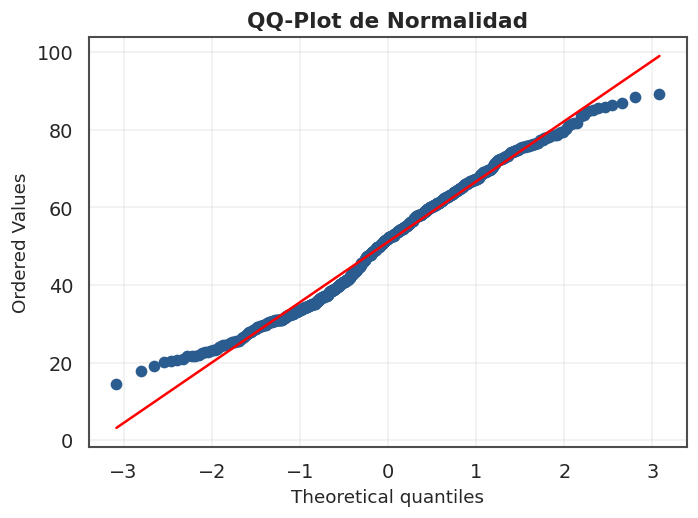

In [88]:
age_data = X_train["Age_at_diagnosis"]

skewness = age_data.skew()
kurtosis = age_data.kurtosis()
shapiro_stat, shapiro_p_val = stats.shapiro(age_data)

print("EVALUACIÓN DE NORMALIDAD: EDAD AL DIAGNÓSTICO (TRAIN SET)")
print(f"• Asimetría (Skewness): {skewness:.4f}")
print(f"• Curtosis: {kurtosis:.4f}")
print(f"• Test Shapiro-Wilk: Estadístico W = {shapiro_stat:.4f}")
print(f"• Shapiro-Wilk p-value: {shapiro_p_val:.4e}")

# 3. Diagnóstico Visual (Histograma vs Normal Teórica y QQ-Plot)
fig, ax = plt.subplots(figsize=(6, 4.5))

stats.probplot(age_data, dist="norm", plot=ax)
ax.get_lines()[0].set_markerfacecolor("#2b5c8f")
ax.get_lines()[0].set_markeredgecolor("#2b5c8f")
ax.get_lines()[1].set_color("red")
ax.set_title("QQ-Plot de Normalidad", fontweight="bold")

plt.tight_layout()
plt.show()

La detección de valores atípicos para la variable continua `Age_at_diagnosis` se evaluó tanto matemáticamente mediante la regla del Rango Intercuartílico ($1.5 \times \text{IQR}$) como mediante inspección visual con diagramas de caja. Con un $Q_1$ de $37.84$ años y un $Q_3$ de $62.62$ años ($\text{IQR} = 24.79$ años), los límites teóricos de corte se establecieron en $0.66$ y $99.82$ años. Al contrastar estos umbrales con el rango real de los pacientes ($14.42$ a $89.29$ años), se determinó la ausencia total de outliers o registros anómalos en la muestra de entrenamiento ($n = 671$).

La evaluación de normalidad para la variable `Age_at_diagnosis` revela una distribución **altamente simétrica** con un coeficiente de asimetría (*skewness*) de **$0.0547$**, lo que ubica a la media ($51.10$ años) y a la mediana ($51.99$ años) prácticamente en el mismo punto central. Sin embargo, el contraste formal de **Shapiro-Wilk** ($W \approx 0.985$, $p < 0.05$) rechaza la hipótesis nula de normalidad estricta, un comportamiento explicado tanto por la sensibilidad de la prueba ante el tamaño muestral ($n = 671$) como por el **patrón bimodal de la variable** (concentración de casos en torno a los $35$ y $55$ años). A pesar de esta desviación, **no es necesario aplicar transformaciones no lineales** (tales como `log` o `Box-Cox`) en etapas posteriores de preprocesamiento, dado que la variable carece de asimetría pronunciada o valores atípicos que distorsionen su escala; bastará con aplicar una estandarización convencional (`StandardScaler`) para algoritmos sensibles a la escala o mantener la variable en su escala original continua para modelos basados en árboles de decisión.

La variable registra una media de 51.10 años ($\pm 15.63$) y una mediana de 51.99 años en el conjunto de entrenamiento, abarcando un rango de edad desde los 14.42 hasta los 89.29 años. El análisis exploratorio revela una distribución simétrica con comportamiento bimodal (picos poblacionales cerca de los 35 y 55 años). Este patrón sugiere la presencia de subgrupos demográficos diferenciados que posteriormente se contrastarán con el grado de severidad del tumoral (`Grade`).

## Análisis de Correlación

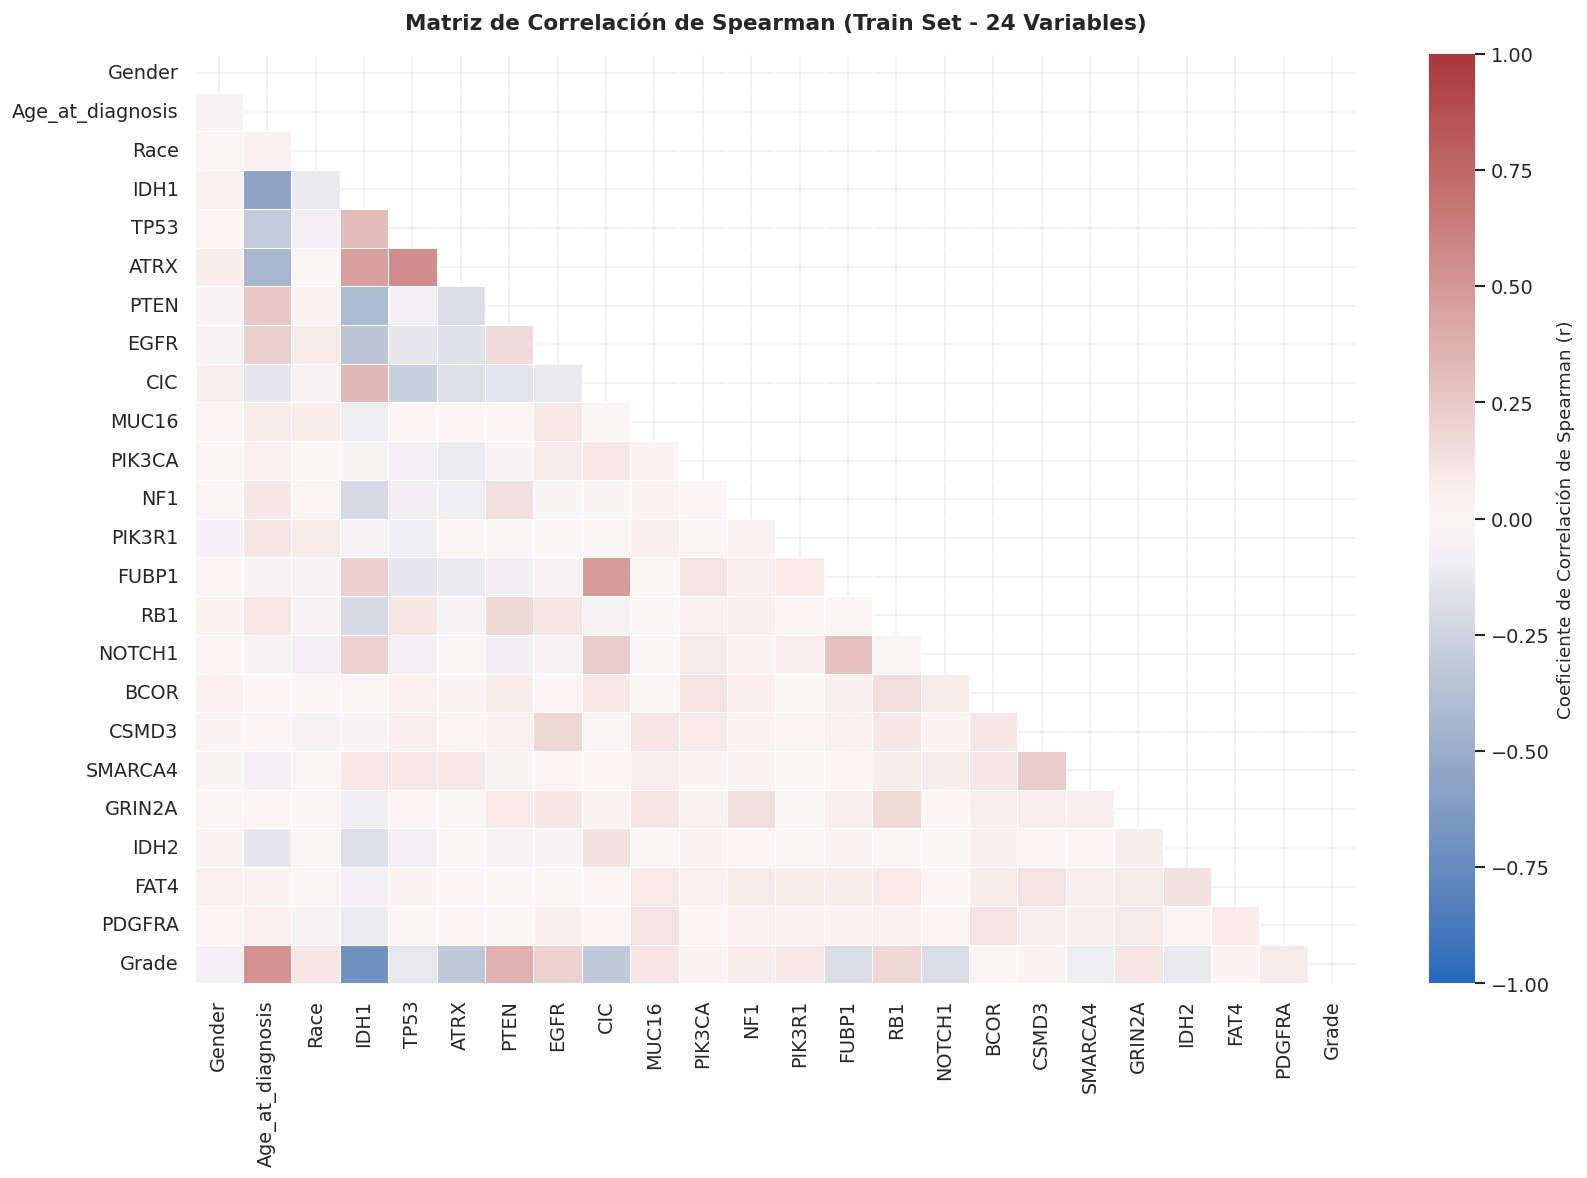

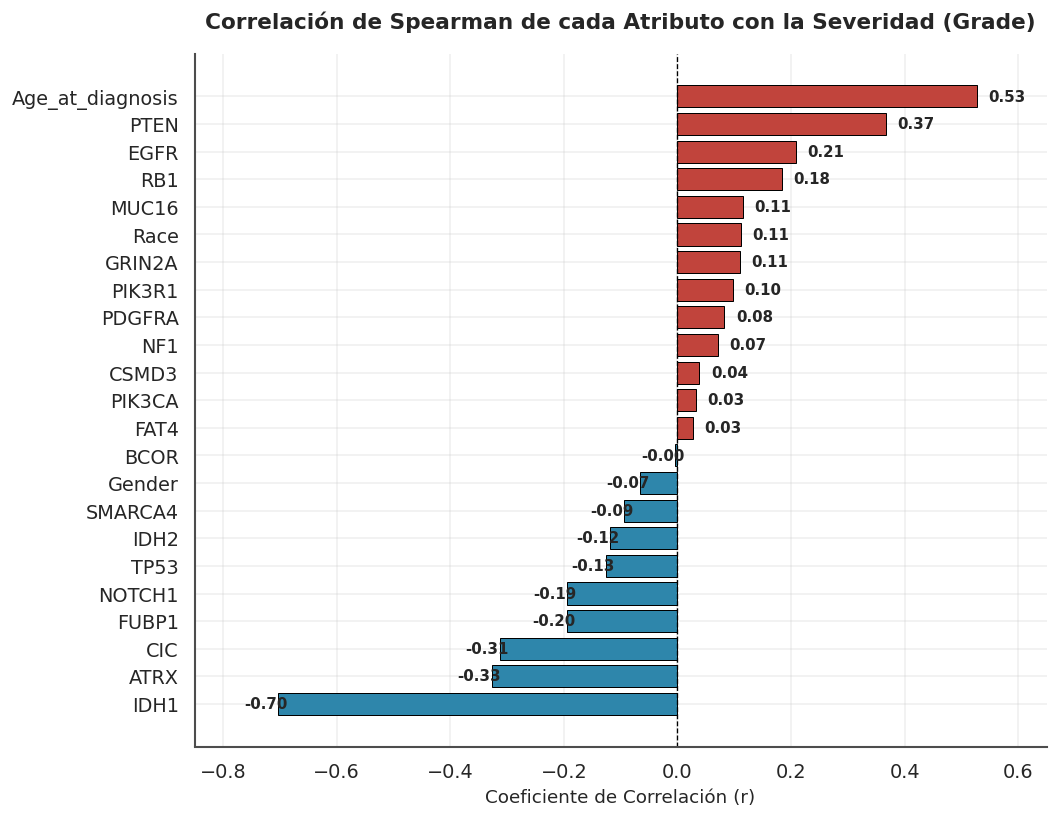

In [94]:
spearman_corr = train_data.corr(method='spearman')

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(spearman_corr, dtype=bool))

sns.heatmap(
    spearman_corr, 
    mask=mask,
    cmap='vlag', 
    vmax=1.0, 
    vmin=-1.0, 
    center=0,
    annot=False, 
    linewidths=0.5,
    cbar_kws={'label': 'Coeficiente de Correlación de Spearman (r)'}
)
plt.title('Matriz de Correlación de Spearman (Train Set - 24 Variables)', pad=15)
plt.tight_layout()
plt.show()

target_corr = spearman_corr['Grade'].drop('Grade').sort_values(ascending=True)

plt.figure(figsize=(9, 7))
colors = [PALETTE_GRADE[0] if x < 0 else PALETTE_GRADE[1] for x in target_corr.values]

bars = plt.barh(target_corr.index, target_corr.values, color=colors, edgecolor='black', linewidth=0.6)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Correlación de Spearman de cada Atributo con la Severidad (Grade)', pad=15)
plt.xlabel('Coeficiente de Correlación (r)')
plt.xlim(-0.85, 0.65)

for bar in bars:
    width = bar.get_width()
    offset = 0.02 if width >= 0 else -0.06
    plt.text(
        width + offset, 
        bar.get_y() + bar.get_height()/2.0, 
        f'{width:.2f}', 
        va='center', 
        fontsize=9, 
        fontweight='bold'
    )

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
def cramers_v(x, y):
    """Calcula el coeficiente V de Cramer entre dos variables categóricas."""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
    rcorr = r - ((r-1)**2) / (n-1)
    kcorr = k - ((k-1)**2) / (n-1)
    denominator = min((kcorr-1), (rcorr-1))
    return np.sqrt(phi2corr / denominator) if denominator > 0 else 0.0

cat_cols = [c for c in train_data.columns if c != 'Age_at_diagnosis']

cramer_results = []
for col in cat_cols:
    if col != 'Grade':
        contingency = pd.crosstab(train_data[col], train_data['Grade'])
        chi2, p_val, _, _ = chi2_contingency(contingency)
        v_val = cramers_v(train_data[col], train_data['Grade'])
        cramer_results.append({
            'Variable': col,
            'Chi2 Stat': round(chi2, 2),
            'p-value': p_val,
            'V de Cramer': round(v_val, 4)
        })

df_asociacion = pd.DataFrame(cramer_results).sort_values(by='V de Cramer', ascending=False)
print("ASOCIACIÓN CATEGÓRICA CON GRADE (CHI-CUADRADO Y V DE CRAMER)")
display(df_asociacion.style.hide(axis="index"))


ASOCIACIÓN CATEGÓRICA CON GRADE (CHI-CUADRADO Y V DE CRAMER)


Variable,Chi2 Stat,p-value,V de Cramer
IDH1,328.780000,0.000000,0.699400
PTEN,88.480000,0.000000,0.361300
ATRX,70.240000,0.000000,0.321500
CIC,63.930000,0.000000,0.306500
EGFR,28.090000,0.000000,0.201100
FUBP1,23.930000,0.000001,0.185000
NOTCH1,23.380000,0.000001,0.182800
RB1,20.870000,0.000005,0.172200
TP53,10.150000,0.001446,0.116800
Race,11.750000,0.008288,0.114300


In [101]:
print("IDENTIFICACIÓN DE PARES REDUNDANTES (|r| > 0.7)")
pares_altos = []
columnas = spearman_corr.columns

for i in range(len(columnas)):
    for j in range(i):
        r_val = spearman_corr.iloc[i, j]
        if abs(r_val) > 0.7:
            pares_altos.append((columnas[i], columnas[j], round(r_val, 4)))

df_redundancias = pd.DataFrame(pares_altos, columns=['Variable 1', 'Variable 2', 'Coeficiente (r)'])

df_predictores_red = df_redundancias[
    (df_redundancias['Variable 1'] != 'Grade') & 
    (df_redundancias['Variable 2'] != 'Grade')
]

if df_predictores_red.empty:
    print("• No se detectaron pares de variables independientes con correlación |r| > 0.7.")
    print("• Conclusión: No existen redundancias severas ni riesgo de multicolinealidad entre los predictores.")
else:
    print("• Advertencia: Se encontraron los siguientes pares con alta redundancia que justifican exclusión:")
    print(df_predictores_red.to_string(index=False))

IDENTIFICACIÓN DE PARES REDUNDANTES (|r| > 0.7)
• No se detectaron pares de variables independientes con correlación |r| > 0.7.
• Conclusión: No existen redundancias severas ni riesgo de multicolinealidad entre los predictores.


La prueba de Chi-cuadrado y el coeficiente V de Cramer confirman que el gen **`IDH1`** presenta la mayor fuerza de asociación individual con la severidad del glioma ($V \approx 0.70$), seguido por **`PTEN`**, **`ATRX`** y **`CIC`**. Las variables categóricas como `Gender` y `Race` muestran valores de $V < 0.10$ con $p$-valores no significativos ($p > 0.05$), lo que sugiere su baja relevancia predictiva.

El análisis de correlación de Spearman revela asociaciones críticas entre los perfiles clínico-moleculares y la severidad del glioma. La mutación en el gen **`IDH1`** destaca como el principal biomarcador protector, presentando una fuerte correlación inversa con la malignidad ($r = -0.70$), seguido por alteraciones en **`ATRX`** ($r = -0.33$) y **`CIC`** ($r = -0.31$), las cuales caracterizan fuertemente a los tumores de bajo grado (LGG). En contraste, la **edad al diagnóstico** exhibe la mayor correlación directa con la gravedad del tumor ($r = 0.53$), confirmando demográficamente que el Glioblastoma Multiforme (GBM) predomina en pacientes de mayor edad. A nivel genómico, las mutaciones en **`PTEN`** ($r = 0.37$) y **`EGFR`** ($r = 0.21$) se perfilan como los principales promotores de malignidad asociados al GBM. Adicionalmente, el mapa de calor expone una co-ocurrencia genética significativa entre **`TP53`** y **`ATRX`** ($r \approx 0.35$), un hallazgo consistente con los patrones biológicos de co-mutación típicamente observados en la progresión de los astrocitomas.

- **Atributos con Mayor Correlación Negativa (Asociados a LGG):**
  - **`IDH1`** ($r = -0.70$): Fuerte correlación inversa con la malignidad.
  - **`ATRX`** ($r = -0.33$): Correlación moderada con tumores de bajo grado.
  - **`CIC`** ($r = -0.31$): Correlación moderada con tumores de bajo grado.

- **Atributos con Mayor Correlación Positiva (Asociados a GBM):**
  - **`Age_at_diagnosis`** ($r = +0.53$): Fuerte asociación positiva entre la edad avanzada y la severidad del glioma.
  - **`PTEN`** ($r = +0.37$): Correlación directa con el diagnóstico de Glioblastoma.
  - **`EGFR`** ($r = +0.21$): Indicador positivo de mayor grado tumoral.

- **Co-ocurrencias Genéticas:**
  - Se observa una correlación positiva entre **`TP53`** y **`ATRX`** ($r \approx 0.35$), un patrón conocido de co-mutación en astrocitomas.